# Training curves: GAP vs flatten head

Confronto tra `Model` (global average pooling) e `ModelLargeHead` (flatten + MLP head), usando gli history salvati durante il training.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src.model import Model, ModelLargeHead

GAP_CSV = "experiments/history_cnn_baseline_gap.csv"
FLATTEN_CSV = "experiments/history_cnn_flatten_head.csv"

DIVERGENCE_EPOCH = 8  

In [14]:
gap_df = pd.read_csv(GAP_CSV)
flatten_df = pd.read_csv(FLATTEN_CSV)

gap_df.head()

,epoch,train_loss,val_loss,val_bal_acc,seconds
0,1,0.502867,0.364007,0.872147,25.26
1,2,0.298604,0.253172,0.893145,6.40
2,3,0.287269,0.264664,0.914822,6.34
3,4,0.247627,0.207657,0.883377,6.33
4,5,0.242045,0.239118,0.815288,6.20


In [15]:
n_params_gap = sum(p.numel() for p in Model().parameters())
n_params_flatten = sum(p.numel() for p in ModelLargeHead().parameters())

print(f"Model (GAP): {n_params_gap:,} params")
print(f"ModelLargeHead (flatten): {n_params_flatten:,} params")

Model (GAP): 97,410 params
ModelLargeHead (flatten): 3,308,802 params


In [16]:
loss_min = min(gap_df["train_loss"].min(), gap_df["val_loss"].min(),
                flatten_df["train_loss"].min(), flatten_df["val_loss"].min())
loss_max = max(gap_df["train_loss"].max(), gap_df["val_loss"].max(),
                flatten_df["train_loss"].max(), flatten_df["val_loss"].max())
loss_pad = (loss_max - loss_min) * 0.05
loss_ylim = (loss_min - loss_pad, loss_max + loss_pad)

bal_acc_min = min(gap_df["val_bal_acc"].min(), flatten_df["val_bal_acc"].min())
bal_acc_max = max(gap_df["val_bal_acc"].max(), flatten_df["val_bal_acc"].max())
bal_acc_pad = (bal_acc_max - bal_acc_min) * 0.05
bal_acc_ylim = (bal_acc_min - bal_acc_pad, bal_acc_max + bal_acc_pad)

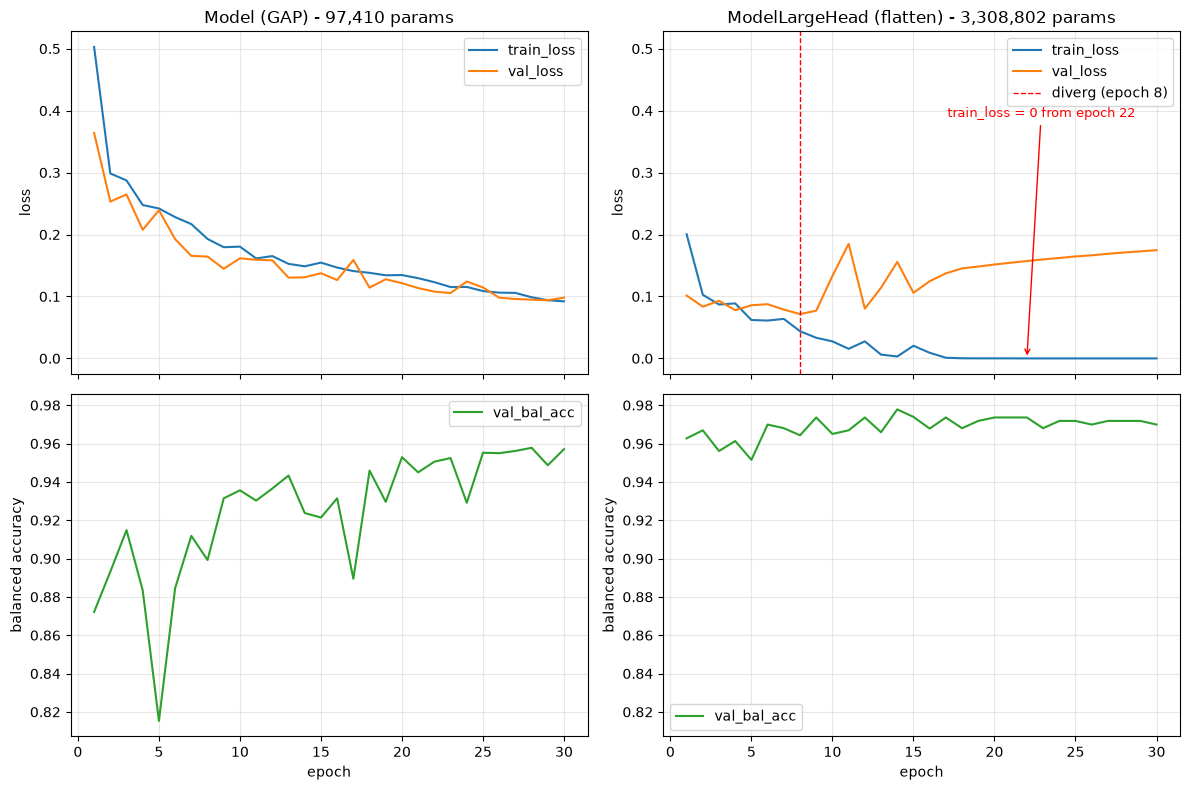

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

columns = [
    (gap_df, f"Model (GAP) - {n_params_gap:,} params", axes[:, 0]),
    (flatten_df, f"ModelLargeHead (flatten) - {n_params_flatten:,} params", axes[:, 1]),
]

for df, title, (ax_loss, ax_acc) in columns:
    ax_loss.plot(df["epoch"], df["train_loss"], label="train_loss")
    ax_loss.plot(df["epoch"], df["val_loss"], label="val_loss")
    ax_loss.set_ylim(loss_ylim)
    ax_loss.set_ylabel("loss")
    ax_loss.set_title(title)
    ax_loss.legend()
    ax_loss.grid(alpha=0.3)

    ax_acc.plot(df["epoch"], df["val_bal_acc"], label="val_bal_acc", color="tab:green")
    ax_acc.set_ylim(bal_acc_ylim)
    ax_acc.set_ylabel("balanced accuracy")
    ax_acc.set_xlabel("epoch")
    ax_acc.legend()
    ax_acc.grid(alpha=0.3)

axes[0, 1].axvline(DIVERGENCE_EPOCH, color="red", linestyle="--", linewidth=1,
                    label=f"diverg (epoch {DIVERGENCE_EPOCH})")
axes[0, 1].legend()

ZERO_LOSS_EPOCH = 22
axes[0, 1].annotate(
    f"train_loss = 0 from epoch {ZERO_LOSS_EPOCH}",
    xy=(ZERO_LOSS_EPOCH, 0),
    xytext=(0.55, 0.75),
    textcoords="axes fraction",
    fontsize=9,
    color="red",
    arrowprops=dict(arrowstyle="->", color="red", lw=1),
)

plt.tight_layout()

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURES_DIR / "gap_vs_flatten_curves.png", dpi=150, bbox_inches="tight")

plt.show()

## Model (GAP), run of 80 epochs


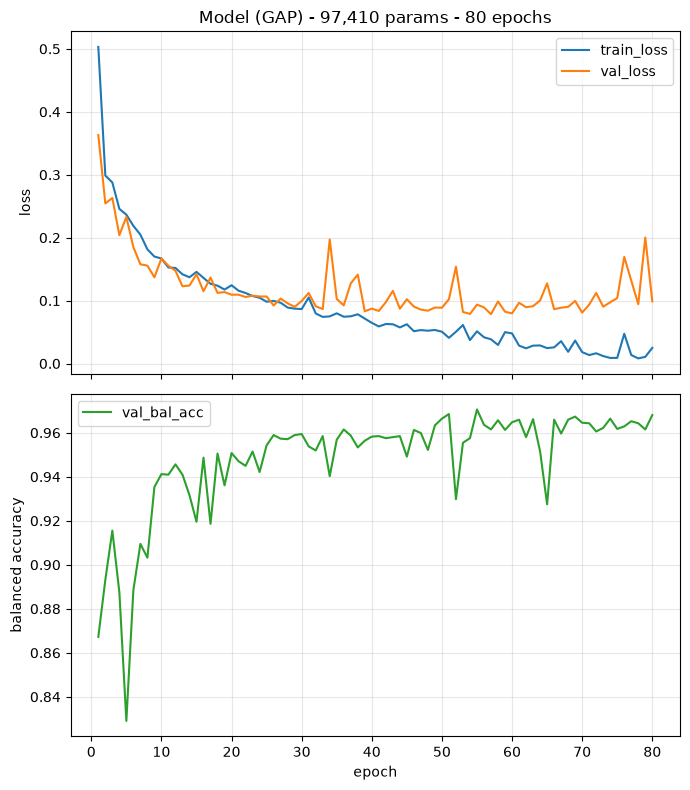

In [19]:
GAP_80_CSV = "experiments/history_cnn_baseline_gap_80_epochs.csv"
gap_80_df = pd.read_csv(GAP_80_CSV)

fig80, (ax_loss80, ax_acc80) = plt.subplots(2, 1, figsize=(7, 8), sharex=True)

ax_loss80.plot(gap_80_df["epoch"], gap_80_df["train_loss"], label="train_loss")
ax_loss80.plot(gap_80_df["epoch"], gap_80_df["val_loss"], label="val_loss")
ax_loss80.set_ylabel("loss")
ax_loss80.set_title(f"Model (GAP) - {n_params_gap:,} params - 80 epochs")
ax_loss80.legend()
ax_loss80.grid(alpha=0.3)

ax_acc80.plot(gap_80_df["epoch"], gap_80_df["val_bal_acc"], label="val_bal_acc", color="tab:green")
ax_acc80.set_ylabel("balanced accuracy")
ax_acc80.set_xlabel("epoch")
ax_acc80.legend()
ax_acc80.grid(alpha=0.3)

plt.tight_layout()

FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig80.savefig(FIGURES_DIR / "gap_80_epochs_curves.png", dpi=150, bbox_inches="tight")

plt.show()